In [1]:
%pip install -r requirements-offline.txt --quiet

/Users/utarn/projects/ml-metrology/.claude/worktrees/issue-26/.check-env/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


# Module M1 — เทรน 3 แบบบนข้อมูลเดียวกัน

**Day 1, 10:15–12:00 · Offline (CPU)** — Lab หลักของ Day 1

เมื่อจบโมดูลนี้ ผู้เรียนจะ **สร้างโมเดลจำแนกภาพด้วยมือเอง 3 วิธี** บน Fashion-MNIST และอธิบายได้ว่าแต่ละวิธีชนะ/แพ้เมื่อไร:

1. **HOG + SVM** — คนออกแบบ feature เอง (ตาราง) แล้วให้ SVM จำแนก
2. **CNN จากศูนย์** — ให้โมเดลเรียนรู้ feature เองจาก pixel ดิบ
3. **Transfer learning** — ยืม feature ที่คนอื่นเทรนมาแล้ว (MobileNetV3 บน ImageNet) freeze backbone + เทรน head ใหม่

แล้วปิดท้ายด้วย **learning curve** บน subset 5% / 25% / 100% — โจทย์จริงของงานเมโทรโลยีคือ "ข้อมูลมีน้อย"

## Dataset / โมเดลที่ใช้ (citation + license)

- **Fashion-MNIST** — Xiao, H., Rasul, K., & Vollgraf, R. (2017). *Fashion-MNIST: a Novel Image Dataset for Benchmarking Machine Learning Algorithms*. arXiv:1708.07747 · แหล่งข้อมูล: <https://github.com/zalandoresearch/fashion-mnist> · **License: MIT** (แจกต่อ/pre-bundle ได้)
- **MobileNetV3-Small weights (ImageNet-1K)** — Howard, A., et al. (2019). *Searching for MobileNetV3*. arXiv:1905.02244 · weights จาก torchvision (<https://github.com/pytorch/vision>, **License: BSD-3-Clause**) เทรนบน ImageNet-1K (Deng et al., 2009, <https://www.image-net.org>) — ใช้เพื่อการศึกษา/วิจัย
- ไลบรารี: scikit-learn (BSD-3-Clause), PyTorch/torchvision (BSD-3-Clause), pandas/matplotlib (BSD)
- ไฟล์ weights จะดาวน์โหลดครั้งแรกลง cache ของ torch (~10 MB) — บนเครื่อง offline ที่ pre-bundle แล้วจะโหลดจากดิสก์ทันที

> **ขอบเขตการรัน:** เพื่อให้แล็บจบในไม่กี่นาทีบน CPU เราใช้ subsample 10,000 train / 2,000 test และเทรนสั้น ๆ — ตัวเลขที่ได้ต่ำกว่าสถิติเผยแพร่ของ Fashion-MNIST ซึ่งใช้ข้อมูลเต็ม + เทรนยาว (ดูสรุปท้ายโมดูล)

## 0. เตรียมข้อมูล

In [2]:
from pathlib import Path


def repo_root() -> Path:
    """หา repo root โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "requirements-offline.txt").exists():
            return p
    raise SystemExit(
        "ไม่พบ repo root — เปิด JupyterLab จาก repo root (uv run jupyter lab)"
    )


import os  # noqa: E402

# Fashion-MNIST: ใช้ datasets/fashion_mnist ที่ pre-bundle ไว้ก่อน
# (git LFS) — ถ้าไม่มีค่อยดาวน์โหลดลง data/ (gitignored) ตามเดิม
_fm = repo_root() / "datasets" / "fashion_mnist" / "FashionMNIST"
if _fm.exists():
    DATA = repo_root() / "datasets" / "fashion_mnist"
else:
    DATA = repo_root() / "data"

# weights ของ torchvision (MobileNetV3) — ใช้ datasets/models/torch
# ที่ pre-bundle ไว้ถ้ามี (torch.hub อ่าน TORCH_HOME ตอนโหลด weights)
_torch = repo_root() / "datasets" / "models" / "torch"
if _torch.exists():
    os.environ["TORCH_HOME"] = str(_torch)


In [3]:
import numpy as np  # noqa: E402
from torchvision.datasets import FashionMNIST  # noqa: E402

# download=True: ดาวน์โหลดครั้งแรกลง data/ (gitignored) — บนเครื่อง
# offline ที่ pre-bundle ไว้แล้ว จะโหลดจากดิสก์ทันทีไม่ใช้เน็ต
train_full = FashionMNIST(root=DATA, train=True, download=True)
test_full = FashionMNIST(root=DATA, train=False, download=True)
print(train_full.data.shape, test_full.data.shape)

torch.Size([60000, 28, 28]) torch.Size([10000, 28, 28])


ดึง **subsample แบบ fix seed** (10k/2k) — ทุกวิธีจะใช้ train/test ชุดเดียวกันเป๊ะ เพื่อให้เทียบกันได้ยุติธรรม:

In [4]:
# fixed subsample 10k/2k — เพื่อให้ทั้ง lab จบในเวลาไม่กี่นาทีบน CPU
# (ผลเมื่อใช้เต็ม 60k/10k อ้างอิงไว้ในสรุปท้ายโมดูล)
N_TRAIN, N_TEST = 10_000, 2_000
rng = np.random.default_rng(42)
idx_tr = rng.choice(len(train_full.data), N_TRAIN, replace=False)
idx_te = rng.choice(len(test_full.data), N_TEST, replace=False)
X_train = train_full.data.numpy()[idx_tr]
y_train = train_full.targets.numpy()[idx_tr]
X_test = test_full.data.numpy()[idx_te]
y_test = test_full.targets.numpy()[idx_te]
print(X_train.shape, X_test.shape)

(10000, 28, 28) (2000, 28, 28)


มองตัวอย่างภาพต่อคลาส — นี่คือข้อมูลเดียวกันที่ทั้ง 3 วิธีจะกิน:

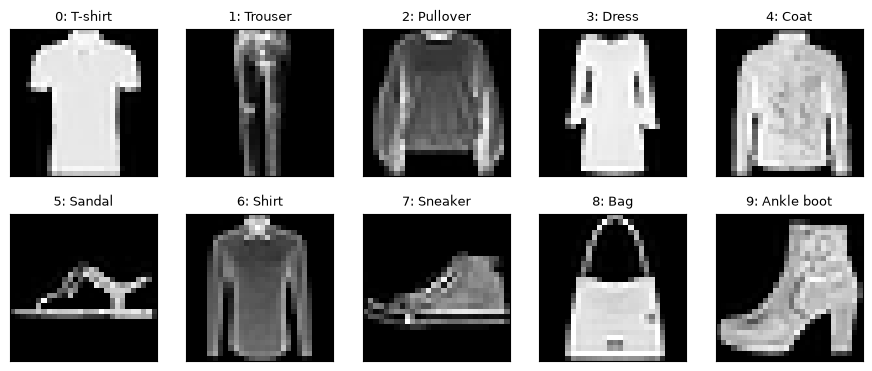

In [5]:
import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = [
    "DejaVu Sans", "Noto Sans Thai", "Leelawadee UI", "Tahoma",
]
CLASS_EN = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]
fig, axes = plt.subplots(2, 5, figsize=(11, 4.4))
for cls in range(10):
    ax = axes[cls // 5][cls % 5]
    i = int(np.flatnonzero(y_train == cls)[0])
    ax.imshow(X_train[i], cmap="gray")
    ax.set_title(f"{cls}: {CLASS_EN[cls]}", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

## 1. วิธีที่ 1 — HOG + SVM: คนออกแบบ feature เอง

**HOG (Histogram of Oriented Gradients):** นับ "ทิศทางของขอบ" ในแต่ละ cell — ภาพ 28×28 แบ่งเป็น cell 4×4 พิกเซล (ได้ 7×7 cells) ในแต่ละ cell นับ histogram 9 bins ของมุม gradient แล้ว normalize → เวกเตอร์ 7×7×9 = **441 มิติ** ต่อภาพ สาระสำคัญ: *ตัวเลขที่โมเดลกิน ถูกออกแบบโดยความรู้ของมนุษย์*

(ด้านล่างเป็น HOG ฉบับย่อเขียนเองด้วย numpy เพื่อเห็นกลไก — งานจริงใช้ `skimage.feature.hog`)

In [6]:
import numpy as np  # noqa: E402


def hog_features(imgs, cell=4, bins=9):
    """HOG แบบย่อ: gradient -> histogram มุมต่อ cell -> L2 normalize.

    imgs: (N, 28, 28) uint8 -> return (N, (28/cell)^2 * bins) float32
    """
    imgs = imgs.astype(np.float32)
    gx = np.empty_like(imgs)
    gy = np.empty_like(imgs)
    gx[:, :, 1:-1] = imgs[:, :, 2:] - imgs[:, :, :-2]
    gy[:, 1:-1, :] = imgs[:, 2:, :] - imgs[:, :-2, :]
    mag = np.hypot(gx, gy)
    ang = np.arctan2(gy, gx) % np.pi
    ny, nx = imgs.shape[1] // cell, imgs.shape[2] // cell
    b = np.floor(ang / (np.pi / bins)).astype(int) % bins
    feats = np.zeros((len(imgs), ny * nx * bins), dtype=np.float32)
    for i in range(len(imgs)):
        f = feats[i].reshape(ny, nx, bins)
        for cy in range(ny):
            for cx in range(nx):
                sl_m = mag[i, cy * cell:(cy + 1) * cell,
                           cx * cell:(cx + 1) * cell]
                sl_b = b[i, cy * cell:(cy + 1) * cell,
                         cx * cell:(cx + 1) * cell]
                f[cy, cx] = np.bincount(
                    sl_b.ravel(), weights=sl_m.ravel(), minlength=bins
                )
        feats[i] = (f / (np.linalg.norm(f) + 1e-6)).ravel()
    return feats

คำนวณ feature ทั้ง train/test แล้วดู "วัตถุดิบ" ของ HOG — magnitude ของ gradient ในแต่ละพิกเซล:

(10000, 441) (2000, 441)


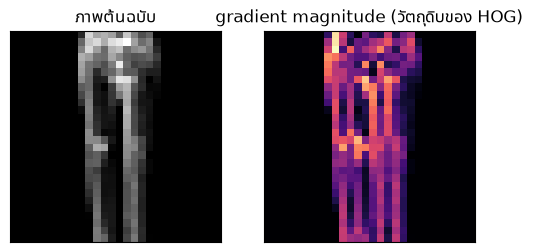

In [7]:
Ftr_hog = hog_features(X_train)
Fte_hog = hog_features(X_test)
print(Ftr_hog.shape, Fte_hog.shape)

demo = X_train[0].astype(np.float32)
gy = np.empty_like(demo)
gx = np.empty_like(demo)
gx[:, 1:-1] = demo[:, 2:] - demo[:, :-2]
gy[1:-1, :] = demo[2:, :] - demo[:-2, :]
mag = np.hypot(gx, gy)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X_train[0], cmap="gray")
axes[0].set_title("ภาพต้นฉบับ")
axes[1].imshow(mag, cmap="magma")
axes[1].set_title("gradient magnitude (วัตถุดิบของ HOG)")
for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])
plt.show()

เทรน **Linear SVM** บน feature 441 มิติ — SVM หาเส้นแบ่งที่ margin กว้างสุด (ทบทวนจากคอร์ส DS):

In [8]:
from sklearn.metrics import accuracy_score  # noqa: E402
from sklearn.svm import LinearSVC  # noqa: E402

svm = LinearSVC(C=1.0, max_iter=5000, dual="auto").fit(Ftr_hog, y_train)
acc_svm = accuracy_score(y_test, svm.predict(Fte_hog))
print(f"HOG + LinearSVC accuracy = {acc_svm:.4f}")

HOG + LinearSVC accuracy = 0.8660


## 2. วิธีที่ 2 — CNN จากศูนย์: ให้โมเดลเรียนรู้ feature เอง

สถาปัตยกรรมจิ๋ว: `Conv(16) → MaxPool → Conv(32) → MaxPool → Flatten → Linear(10)` — ชั้น conv เรียนรู้ "ตัวกรองรูปแบบ" (ขอบ → มุม → ทรง) จาก pixel ดิบเอง ไม่มีใครออกแบบให้

เทรน **10 epochs** ด้วย Adam บน train set 10k ภาพ (บน CPU ใช้เวลาไม่กี่สิบวินาที):

In [9]:
import torch  # noqa: E402
import torch.nn as nn  # noqa: E402
from torch.utils.data import DataLoader, TensorDataset  # noqa: E402

Xtr_t = torch.from_numpy(X_train).float().unsqueeze(1) / 255.0
Xte_t = torch.from_numpy(X_test).float().unsqueeze(1) / 255.0
ytr_t = torch.from_numpy(y_train)
mean, std = Xtr_t.mean(), Xtr_t.std()
Xtr_n = (Xtr_t - mean) / std
Xte_n = (Xte_t - mean) / std
print(f"normalize: mean={mean:.4f} std={std:.4f}")


class SmallCNN(nn.Module):
    """CNN จิ๋ว 2 ชั้น conv — ตั้งใจให้เล็กพอรันบน CPU ได้เร็ว."""

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(32 * 7 * 7, 10),
        )

    def forward(self, x):
        return self.net(x)


def train_cnn(X, y, epochs=10, bs=128, seed=0, log_every=0):
    """เทรน CNN ด้วย Adam คืนโมเดลที่เทรนแล้ว."""
    torch.manual_seed(seed)
    model = SmallCNN()
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed)
    dl = DataLoader(
        TensorDataset(X, y), batch_size=bs, shuffle=True, generator=g
    )
    for ep in range(epochs):
        model.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
        if log_every and (ep + 1) % log_every == 0:
            print(f"  epoch {ep + 1}/{epochs}: loss={loss.item():.4f}")
    return model


def cnn_accuracy(model):
    model.eval()
    with torch.no_grad():
        pred = model(Xte_n).argmax(1).numpy()
    return accuracy_score(y_test, pred)

normalize: mean=0.2867 std=0.3535


In [10]:
from sklearn.metrics import accuracy_score  # noqa: E402

cnn = train_cnn(Xtr_n, ytr_t, epochs=10, log_every=2)
acc_cnn = cnn_accuracy(cnn)
print(f"CNN from scratch accuracy = {acc_cnn:.4f}")

  epoch 2/10: loss=0.1989


  epoch 4/10: loss=0.2494


  epoch 6/10: loss=0.4792


  epoch 8/10: loss=0.3786


  epoch 10/10: loss=0.3535
CNN from scratch accuracy = 0.8745


## 3. วิธีที่ 3 — Transfer learning: ยืม feature ที่คนอื่นเทรนมาแล้ว

**ไอเดีย:** MobileNetV3 เทรนมาบน ImageNet (1.2 ล้านภาพ, 1,000 คลาส) — ชั้นต้น ๆ ของมันรู้จักขอบ/พื้นผิว/ทรงทั่วไปอยู่แล้ว เราจึง:

1. **Freeze backbone** (น้ำหนัก ImageNet ทั้งหมด — ไม่แตะ)
2. **เทรนเฉพาะ head** ใหม่ (Linear 576→64→10) บน feature ที่ดึงออกมาแล้ว

การดึง feature ล่วงหน้า (12k ภาพผ่าน backbone) ใช้เวลาไม่กี่นาทีบน CPU — ทำ **ครั้งเดียว** แล้วเทรน head ได้เร็วมาก (จะเทรนใหม่หลายรอบใน learning curve ก็ได้)

In [11]:
import torchvision.models as tvm  # noqa: E402
# (torch / nn / DataLoader ถูก import ไว้แล้วตั้งแต่หัวข้อ 2)

mob = tvm.mobilenet_v3_small(
    weights=tvm.MobileNet_V3_Small_Weights.IMAGENET1K_V1
)
# backbone = ทุกชั้นจนถึง global average pool -> เวกเตอร์ 576 มิติ
backbone = nn.Sequential(mob.features, mob.avgpool, nn.Flatten())
for p in backbone.parameters():
    p.requires_grad_(False)  # freeze — จะไม่อัปเดตน้ำหนัก ImageNet
backbone.eval()
n_params = sum(p.numel() for p in backbone.parameters())
print(f"backbone params: {n_params:,} (ทั้งหมด freeze)")


def extract_features(imgs_u8, size=96, bs=256):
    """u8 (N,28,28) -> features (N, 576) ผ่าน frozen backbone.

    28px ขาวดำ -> resize 96px -> ซ้ำ 3 ช่องให้เป็น RGB ที่ backbone คาด
    """
    x = torch.from_numpy(imgs_u8).float().unsqueeze(1) / 255.0
    x = torch.nn.functional.interpolate(
        x, size=(size, size), mode="bilinear"
    )
    x = x.repeat(1, 3, 1, 1)
    out = []
    with torch.no_grad():
        for i in range(0, len(x), bs):
            out.append(backbone(x[i:i + bs]))
    return torch.cat(out)


print("extract features train ...")
Ftr_m = extract_features(X_train)
print("extract features test ...")
Fte_m = extract_features(X_test)
print(Ftr_m.shape, Fte_m.shape)

backbone params: 927,008 (ทั้งหมด freeze)
extract features train ...


extract features test ...


torch.Size([10000, 576]) torch.Size([2000, 576])


เทรน head 30 epochs บน feature ที่ดึงไว้ — เร็วมากเพราะ backbone ไม่ต้องรันซ้ำ:

In [12]:
def train_head(feats, y, epochs=30, seed=0):
    """เทรน head เล็ก (Linear 576->64->10) บน feature ที่ดึงไว้แล้ว."""
    torch.manual_seed(seed)
    head = nn.Sequential(
        nn.Linear(feats.shape[1], 64), nn.ReLU(), nn.Linear(64, 10)
    )
    opt = torch.optim.Adam(head.parameters(), lr=1e-3)
    loss_fn = nn.CrossEntropyLoss()
    g = torch.Generator().manual_seed(seed)
    dl = DataLoader(
        TensorDataset(feats, y), batch_size=128, shuffle=True,
        generator=g,
    )
    for ep in range(epochs):
        head.train()
        for xb, yb in dl:
            opt.zero_grad()
            loss = loss_fn(head(xb), yb)
            loss.backward()
            opt.step()
    return head


def head_accuracy(head):
    head.eval()
    with torch.no_grad():
        pred = head(Fte_m).argmax(1).numpy()
    return accuracy_score(y_test, pred)

In [13]:
from sklearn.metrics import accuracy_score  # noqa: E402

head = train_head(Ftr_m, ytr_t, epochs=30)
acc_head = head_accuracy(head)
print(f"Transfer (MobileNetV3 frozen + head) accuracy = {acc_head:.4f}")

Transfer (MobileNetV3 frozen + head) accuracy = 0.8535


## 4. เทียบ 3 วิธี — accuracy + confusion matrix

          method  test accuracy
       HOG + SVM         0.8660
CNN from scratch         0.8745
 Transfer (MNV3)         0.8535


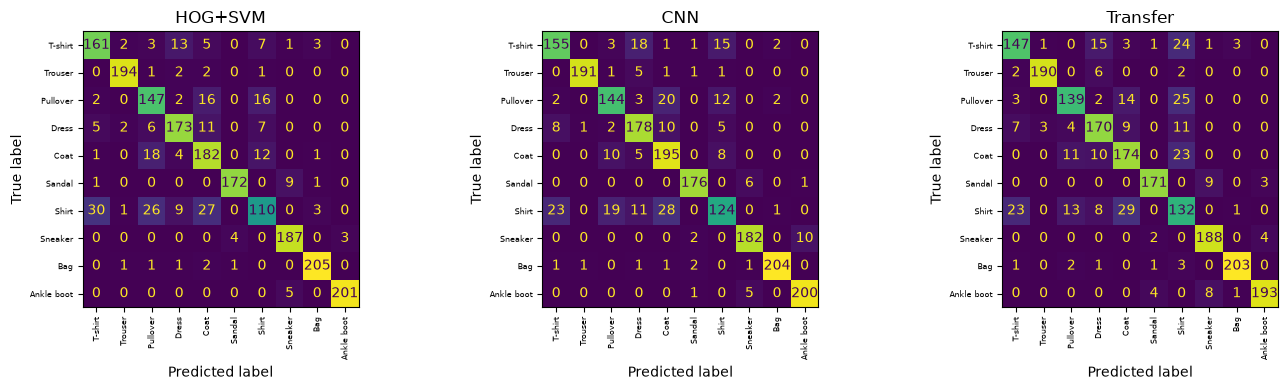

In [14]:
import pandas as pd  # noqa: E402
from sklearn.metrics import ConfusionMatrixDisplay  # noqa: E402


def preds_svm():
    return svm.predict(Fte_hog)


def preds_cnn():
    cnn.eval()
    with torch.no_grad():
        return cnn(Xte_n).argmax(1).numpy()


def preds_head():
    head.eval()
    with torch.no_grad():
        return head(Fte_m).argmax(1).numpy()


summary = pd.DataFrame(
    {
        "method": ["HOG + SVM", "CNN from scratch", "Transfer (MNV3)"],
        "test accuracy": [acc_svm, acc_cnn, acc_head],
    }
)
print(summary.round(4).to_string(index=False))

models = [
    ("HOG+SVM", preds_svm),
    ("CNN", preds_cnn),
    ("Transfer", preds_head),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, fn) in zip(axes, models):
    ConfusionMatrixDisplay.from_predictions(
        y_test, fn(), ax=ax, colorbar=False, xticks_rotation=90
    )
    ax.set_title(name)
    ax.set_xticklabels(CLASS_EN, fontsize=6)
    ax.set_yticklabels(CLASS_EN, fontsize=6)
plt.tight_layout()
plt.show()

**อ่าน confusion matrix ร่วมกัน:** ช่องสีเข้มนอกแนวทแยง = คู่คลาสที่สับสน มักเป็น **Shirt ↔ T-shirt/Pullover/Coat** — เสื้อผ้าทรงคล้ายกันในภาพขาวดำ 28×28 ลองเทียบด้วยว่า CNN พลาดรูปแบบไปทางไหนต่างจาก HOG+SVM อย่างไร

**อ่านตาราง accuracy:** บนข้อมูล 10k นี้ สามวิธีอยู่ในช่วงใกล้กัน (ราว 85–88%) — CNN จากศูนย์มักได้นำเล็กน้อย ไม่ใช่เพราะ deep learning "ไม่เก่ง" แต่เพราะ (1) ภาพ 28×28 ขาวดำง่ายพอให้ HOG ทำงานได้ดี และ (2) เราเทรนสั้น/ข้อมูลน้อย ยิ่งข้อมูลเยอะ CNN ยิ่งถล่ม (ดู learning curve ต่อไป)

**บทเรียนสำคัญกว่าตัวเลข:** ถ้าโจทย์จริงของคุณเป็นภาพเมโทรโลยี (ขอบ, รอย, พื้นผิว) HOG อาจชนะได้บนข้อมูลน้อย — ลองวิธีง่ายก่อนเสมอ

## 5. Learning curve — ข้อมูลน้อยแค่ไหนยังพอ?

**โจทย์เมโทรโลยีจริง:** มีภาพให้เทรนแค่หลักร้อย — ไม่ใช่หลักหมื่น เราจะเทรน **จริงทุกวิธี** บน subset 5% (500), 25% (2,500), 100% (10,000) แล้ววาด accuracy ต่อจำนวนข้อมูล (test set คงที่ 2k — เทียบข้ามจุดได้ยุติธรรม)

แต่ละวิธีเทรนใหม่ทุกจุด: HOG+SVM วินาทีเดียว, CNN 10 epochs, head บน feature ที่ดึงไว้แล้ว — รวมไม่ถึงนาที

In [15]:
fractions = [0.05, 0.25, 1.0]
curve = {"HOG+SVM": [], "CNN": [], "Transfer": []}
for frac in fractions:
    n = int(N_TRAIN * frac)
    print(f"--- n = {n} ({frac:.0%}) ---")
    svm_n = LinearSVC(C=1.0, max_iter=5000, dual="auto").fit(
        Ftr_hog[:n], y_train[:n]
    )
    acc_n = accuracy_score(y_test, svm_n.predict(Fte_hog))
    curve["HOG+SVM"].append(acc_n)
    cnn_n = train_cnn(Xtr_n[:n], ytr_t[:n], epochs=10)
    curve["CNN"].append(cnn_accuracy(cnn_n))
    head_n = train_head(Ftr_m[:n], ytr_t[:n], epochs=30)
    curve["Transfer"].append(head_accuracy(head_n))
    print("  " + "  ".join(
        f"{k}={v[-1]:.4f}" for k, v in curve.items()
    ))

--- n = 500 (5%) ---


  HOG+SVM=0.8170  CNN=0.7335  Transfer=0.7665
--- n = 2500 (25%) ---


  HOG+SVM=0.8450  CNN=0.8285  Transfer=0.8155
--- n = 10000 (100%) ---


  HOG+SVM=0.8660  CNN=0.8745  Transfer=0.8535


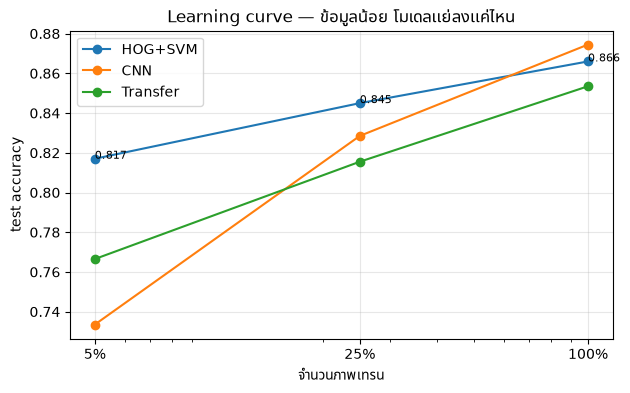

ตรวจแนวโน้ม (5% < 25% < 100%):
  HOG+SVM: 0.817 -> 0.845 -> 0.866  ถูกทิศทาง: True
  CNN: 0.734 -> 0.829 -> 0.875  ถูกทิศทาง: True
  Transfer: 0.766 -> 0.816 -> 0.854  ถูกทิศทาง: True


In [16]:
fig, ax = plt.subplots(figsize=(7, 4))
ns = [int(N_TRAIN * f) for f in fractions]
for name, accs in curve.items():
    ax.plot(ns, accs, "o-", label=name)
for n, a in zip(ns, curve["HOG+SVM"]):
    ax.annotate(f"{a:.3f}", (n, a), fontsize=8)
ax.set_xscale("log")
ax.set_xticks(ns, [f"{p:.0%}" for p in fractions])
ax.set_xlabel("จำนวนภาพเทรน")
ax.set_ylabel("test accuracy")
ax.set_title("Learning curve — ข้อมูลน้อย โมเดลแย่ลงแค่ไหน")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

print("ตรวจแนวโน้ม (5% < 25% < 100%):")
for name, accs in curve.items():
    ok = accs[0] < accs[1] < accs[2]
    print(f"  {name}: {accs[0]:.3f} -> {accs[1]:.3f} -> "
          f"{accs[2]:.3f}  ถูกทิศทาง: {ok}")

**อ่าน learning curve สามเส้น:**

- **ทุกวิธีแย่ลงเมื่อข้อมูลน้อย** — แนวโน้มถูกทิศทางทั้งสามเส้น นี่คือ "ราคาที่ต้องจ่าย" เมื่อข้อมูลมีจำกัด
- **ที่ 500 ภาพ HOG+SVM มักนำ** — feature ที่คนออกแบบมาช่วยชดเชยข้อมูลที่ขาด ส่วน CNN/transfer ที่ต้อง "เรียนรู้" ยังไม่มีอาหารพอ
- **ยิ่งข้อมูลเยอะ CNN ยิ่งไล่ทัน/แซง** — ความสามารถเรียนรู้ feature เองคืนมาเมื่อมีข้อมูลพอ

**ข้อคิดสำหรับงานเมโทรโลยี:** ข้อมูลน้อย ≠ ทำ ML ไม่ได้ — แต่ต้องเลือกอาวุธให้ถูก (feature ที่ออกแบบดี / transfer learning / augmentation — จะเจอใน M6)

## 6. สรุป

| วิธี | ใครออกแบบ feature | เทรนอะไร | จุดแข็ง |
|---|---|---|---|
| HOG + SVM | มนุษย์ | SVM (นาที) | ข้อมูลน้อยก็ไปได้, ตีความง่าย |
| CNN จากศูนย์ | โมเดล | ทั้ง feature + ตัวจำแนก | ยิ่งข้อมูลเยอะยิ่งแรง |
| Transfer | ImageNet (ยืม) | head เท่านั้น | ข้อมูลน้อย + ภาพจริงสี |

**ตัวเลขบน Fashion-MNIST ชุดเต็ม (อ้างอิงที่เผยแพร่, ไม่ใช่ของแล็บนี้):** HOG+SVM ~90%, CNN เทรนเต็ม ~93–94% — แล็บนี้ใช้ 10k/เทรนสั้นเพื่อให้รันจบบน CPU ภายในไม่กี่นาที ถ้าอยากเห็นตัวเลขระดับสถิติ ลองเพิ่ม `N_TRAIN = 60_000` และ epochs (แต่เตรียมเวลาเป็นชั่วโมงบน CPU)

**ต่อไป (M2):** เปลี่ยน modality ไป OCR — วัดผลโมเดลด้วย CER แทน accuracy